# Category Quantization

This notebook loads video embeddings for channels, trains a dynamic k-means clustering model per channel to categorize their videos into distinct semantic clusters, and visualizes the video geometries per channel.

## 1) Setup and Data Loading
Import required libraries, define configuration, and load the dataset from the canonical Google Drive path (with local fallback).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive if available
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
except ImportError:
    print('Not running in Colab; skipping drive mount.')

CONFIG = {
    'input_csv': Path('/content/drive/MyDrive/Graphiko/exports/video_embeddings_reduced/latest/business_cluster_video_embeddings_reduced_20d.csv'),
    'fallback_inputs': [
        Path('src/Graphiko/data/business_cluster_video_embeddings_reduced_20d.csv'),
        Path('data/business_cluster_video_embeddings_reduced_20d.csv'),
    ],
    'embedding_dim': 20,
    'min_clusters': 4,
    'max_clusters': 10,
    'random_seed': 42
}

np.random.seed(CONFIG['random_seed'])

def load_data():
    paths_to_try = [CONFIG['input_csv']] + CONFIG['fallback_inputs']
    for p in paths_to_try:
        if p.exists():
            print(f'Loaded from: {p}')
            return pd.read_csv(p)
    raise FileNotFoundError('Could not find embedding data. Ensure the CSV is available at one of the configured paths.')

df = load_data()
print(f'Dataset shape: {df.shape}')

# Ensure embedding columns are present
embed_cols = [f'embedding_reduced_{i:02d}' for i in range(1, CONFIG['embedding_dim'] + 1)]
missing = [c for c in embed_cols if c not in df.columns]
if missing:
    raise ValueError(f'Missing embedding columns: {missing}')

# Use channel_name consistently
if 'channel_name' not in df.columns:
    if 'channel_title' in df.columns:
         df['channel_name'] = df['channel_title']
    else:
         df['channel_name'] = df['channel_id'] # Fallback

df.head()


Not running in Colab; skipping drive mount.
Loaded from: data/business_cluster_video_embeddings_reduced_20d.csv
Dataset shape: (10, 30)


,video_id,channel_id,channel_name,video_title,view_count,like_count,comment_count,date_created_1,date_created_2,date_published,...,embedding_reduced_11,embedding_reduced_12,embedding_reduced_13,embedding_reduced_14,embedding_reduced_15,embedding_reduced_16,embedding_reduced_17,embedding_reduced_18,embedding_reduced_19,embedding_reduced_20
0,v1,c1,Channel One,Video 1,100,10,1,2023-01-01,NaN,2023-01-01,...,0.20,0.30,0.40,0.50,0.60,0.70,0.80,0.90,0.10,0.20
1,v2,c1,Channel One,Video 2,150,15,2,2023-01-02,NaN,2023-01-02,...,0.21,0.31,0.41,0.51,0.61,0.71,0.81,0.91,0.11,0.21
2,v3,c1,Channel One,Video 3,200,20,3,2023-01-03,NaN,2023-01-03,...,0.80,0.70,0.60,0.50,0.40,0.30,0.20,0.10,0.90,0.80
3,v4,c1,Channel One,Video 4,250,25,4,2023-01-04,NaN,2023-01-04,...,0.81,0.71,0.61,0.51,0.41,0.31,0.21,0.11,0.91,0.81
4,v5,c1,Channel One,Video 5,300,30,5,2023-01-05,NaN,2023-01-05,...,0.50,0.50,0.50,0.50,0.50,0.50,0.50,0.50,0.50,0.50


## 2) Dynamic K-Means Clustering per Channel
We group the videos by `channel_name` (falling back to `channel_id` if names are missing/duplicates). For each channel, we train a k-means clustering model on the 20D embeddings to find semantic categories. The optimal number of clusters ($k$) is dynamically selected between a minimum of 4 and a maximum of 10, optimizing for cluster separability via the Silhouette score.

In [2]:
def optimize_kmeans(embeddings, min_k=4, max_k=10, random_seed=42):
    """
    Finds the optimal number of clusters for a given set of embeddings using Silhouette score.
    """
    n_samples = embeddings.shape[0]
    # Ensure we don't try to find more clusters than samples available (or minimal k)
    actual_max_k = min(max_k, n_samples - 1)
    actual_min_k = min(min_k, actual_max_k)
    
    if actual_max_k < 2:
        # Not enough samples to cluster, just return 1 cluster
        model = KMeans(n_clusters=1, random_state=random_seed, n_init='auto')
        return model.fit(embeddings), 1
        
    best_score = -1
    best_k = actual_min_k
    best_model = None
    
    for k in range(actual_min_k, actual_max_k + 1):
        model = KMeans(n_clusters=k, random_state=random_seed, n_init='auto')
        labels = model.fit_predict(embeddings)
        
        # Silhouette score requires at least 2 clusters and 2 samples
        if len(set(labels)) > 1:
            score = silhouette_score(embeddings, labels)
            if score > best_score:
                best_score = score
                best_k = k
                best_model = model
                
    # Fallback if no valid model found
    if best_model is None:
        best_k = actual_min_k
        best_model = KMeans(n_clusters=best_k, random_state=random_seed, n_init='auto').fit(embeddings)
        
    return best_model, best_k

# Group by channel and compute clusters
channel_clusters = {}
df['cluster_id'] = -1

for channel, group in df.groupby('channel_name'):
    print(f"Processing channel: {channel} ({len(group)} videos)")
    # Extract the 20D embeddings for this channel's videos
    embeddings = group[embed_cols].values
    
    if len(embeddings) < 2:
        print(f"  Skipping {channel}: Not enough videos.")
        df.loc[group.index, 'cluster_id'] = 0
        continue
        
    # Train model
    model, optimal_k = optimize_kmeans(
        embeddings, 
        min_k=CONFIG['min_clusters'], 
        max_k=CONFIG['max_clusters'],
        random_seed=CONFIG['random_seed']
    )
    
    # Assign cluster labels
    labels = model.labels_
    df.loc[group.index, 'cluster_id'] = labels
    
    # Store the model and cluster centers for later
    channel_clusters[channel] = {
        'model': model,
        'optimal_k': optimal_k,
        'centers': model.cluster_centers_,
        'video_indices': group.index
    }
    print(f"  -> Optimal clusters (k): {optimal_k}")


Processing channel: Channel One (10 videos)


  -> Optimal clusters (k): 5


## 3) Polygon / Cluster Visualization
This section defines a function to visualize the semantic polygon of a given channel. The 20-dimensional embeddings are projected onto a 2D plane via PCA, with the videos represented as dots colored by their computed cluster. It also outputs a table of video titles with their assigned cluster names for context.

Setting up example for channel: Channel One


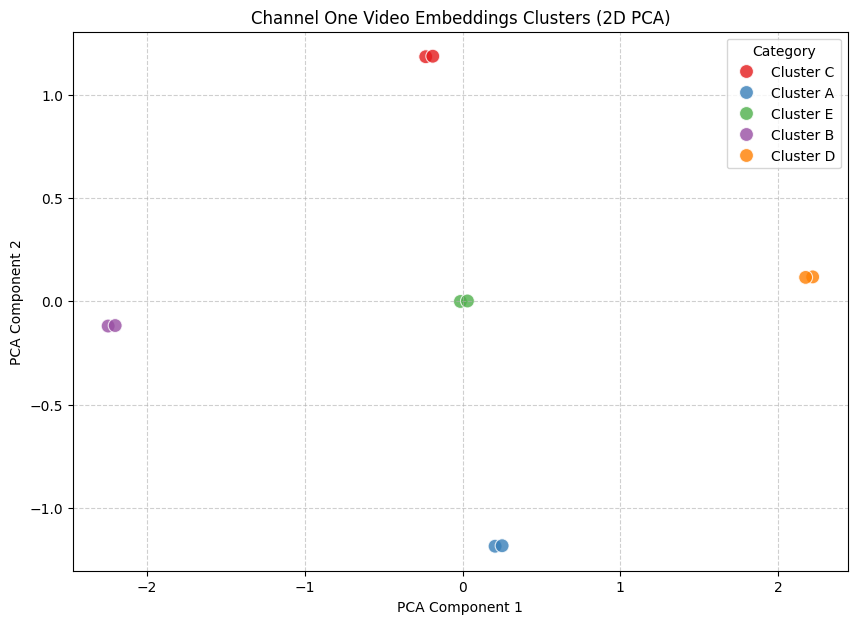


Sample Table for Channel One:


,video_title,cluster_name
2,Video 3,Cluster A
3,Video 4,Cluster A
6,Video 7,Cluster B
7,Video 8,Cluster B
0,Video 1,Cluster C
1,Video 2,Cluster C
8,Video 9,Cluster D
9,Video 10,Cluster D
4,Video 5,Cluster E
5,Video 6,Cluster E


In [3]:
def visualize_channel_clusters(channel_name, dataframe, embed_cols):
    """
    Visualizes the clustered videos for a given channel in a 2D scatter plot (using PCA) 
    and displays a sample table of video titles and their cluster assignments.
    """
    # Filter dataframe for the target channel
    group = dataframe[dataframe['channel_name'] == channel_name].copy()
    
    if group.empty:
        print(f"No data found for channel: {channel_name}")
        return
        
    embeddings = group[embed_cols].values
    
    # Create generic cluster names (e.g. 'Cluster A', 'Cluster B')
    cluster_mapping = {c: f"Cluster {chr(65 + c)}" for c in group['cluster_id'].unique()}
    group['cluster_name'] = group['cluster_id'].map(cluster_mapping)
    
    # 2D projection via PCA for visualization
    if embeddings.shape[1] > 2:
        pca = PCA(n_components=2, random_state=42)
        proj_2d = pca.fit_transform(embeddings)
    else:
        proj_2d = embeddings
        
    group['pca_x'] = proj_2d[:, 0]
    group['pca_y'] = proj_2d[:, 1]
    
    # Create plot
    plt.figure(figsize=(10, 7))
    sns.scatterplot(
        data=group, 
        x='pca_x', 
        y='pca_y', 
        hue='cluster_name', 
        palette='Set1', 
        s=100, 
        alpha=0.8
    )
    
    plt.title(f"{channel_name} Video Embeddings Clusters (2D PCA)")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.legend(title="Category")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
    
    # Display sample table
    print(f"\nSample Table for {channel_name}:")
    # Sort by cluster_id, display top 15
    sample_df = group[['video_title', 'cluster_name']].sort_values('cluster_name')
    display(sample_df.head(15))

if len(channel_clusters) > 0:
    # Setup an example using the first available channel
    example_channel = list(channel_clusters.keys())[0]
    print(f"Setting up example for channel: {example_channel}")
    visualize_channel_clusters(example_channel, df, embed_cols)
else:
    print("No channels were clustered.")
